# HBank - Simple - Gertler Karadi


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sequence_jacobian import simple, solved, combine, create_model  # functions
from sequence_jacobian import grids, hetblocks                       # modules

In [2]:
### Single HH
from numba import guvectorize
from sequence_jacobian.blocks.het_block import het
from sequence_jacobian import interpolate
import scipy.linalg

def hh_init(b_grid, a_grid, z_grid, eis, h, C_lag):
    # Initialise with habit-adjusted consumption proxy so backward iter starts near the solution
    x_a = np.maximum(0.6 + 1.1 * b_grid[:, np.newaxis] + a_grid - h * C_lag, 0.1)
    x_b = np.maximum(0.5 + b_grid[:, np.newaxis] + 1.2 * a_grid - h * C_lag, 0.1)
    Va = x_a ** (-1 / eis) * np.ones((z_grid.shape[0], 1, 1))
    Vb = x_b ** (-1 / eis) * np.ones((z_grid.shape[0], 1, 1))
    return Va, Vb

def adjustment_costs(a, a_grid, ra, chi0, chi1, chi2):
    adj_cost = get_Psi_and_deriv(a, a_grid, ra, chi0, chi1, chi2)[0]
    return adj_cost

def marginal_cost_grid(a_grid, ra, chi0, chi1, chi2):
    Psi1 = get_Psi_and_deriv(a_grid[:, np.newaxis],
                             a_grid[np.newaxis, :], ra, chi0, chi1, chi2)[1]
    return Psi1

@het(exogenous='Pi', policy=['b', 'a'], backward=['Vb', 'Va'],
     hetinputs=[marginal_cost_grid], hetoutputs=[adjustment_costs], backward_init=hh_init)
def hh(Va_p, Vb_p, a_grid, b_grid, z_grid, e_grid, k_grid,beta, eis, rb, ra, chi0, chi1, chi2, Psi1,h, C_lag):
    Wb = beta * Vb_p
    Wa = beta * Va_p
    W_ratio = Wa / Wb

    i, pi = lhs_equals_rhs_interpolate(W_ratio, 1 + Psi1)
    a_endo_unc = interpolate.apply_coord(i, pi, a_grid)
    c_endo_unc = interpolate.apply_coord(i, pi, Wb) ** (-eis) + h * C_lag

    b_endo = (c_endo_unc + a_endo_unc + addouter(-z_grid, b_grid, -(1 + ra) * a_grid)
              + get_Psi_and_deriv(a_endo_unc, a_grid, ra, chi0, chi1, chi2)[0]) / (1 + rb)

    i, pi = interpolate.interpolate_coord(b_endo.swapaxes(1, 2), b_grid)
    a_unc = interpolate.apply_coord(i, pi, a_endo_unc.swapaxes(1, 2)).swapaxes(1, 2)
    b_unc = interpolate.apply_coord(i, pi, b_grid).swapaxes(1, 2)

    lhs_con = W_ratio[:, 0:1, :] / (1 + k_grid[np.newaxis, :, np.newaxis])
    i, pi = lhs_equals_rhs_interpolate(lhs_con, 1 + Psi1)
    a_endo_con = interpolate.apply_coord(i, pi, a_grid)
    c_endo_con = ((1 + k_grid[np.newaxis, :, np.newaxis]) ** (-eis)
              * interpolate.apply_coord(i, pi, Wb[:, 0:1, :]) ** (-eis)) + h * C_lag

    b_endo = (c_endo_con + a_endo_con
              + addouter(-z_grid, np.full(len(k_grid), b_grid[0]), -(1 + ra) * a_grid)
              + get_Psi_and_deriv(a_endo_con, a_grid, ra, chi0, chi1, chi2)[0]) / (1 + rb)

    a_con = interpolate.interpolate_y(b_endo.swapaxes(1, 2), b_grid,
                                      a_endo_con.swapaxes(1, 2)).swapaxes(1, 2)

    a, b = a_unc.copy(), b_unc.copy()
    b[b <= b_grid[0]] = b_grid[0]
    a[b <= b_grid[0]] = a_con[b <= b_grid[0]]

    Psi, _, Psi2 = get_Psi_and_deriv(a, a_grid, ra, chi0, chi1, chi2)

    c = addouter(z_grid, (1 + rb) * b_grid, (1 + ra) * a_grid) - Psi - a - b
    # Floor: when C_lag is off steady state, c - h*C_lag can be negative for poor agents
    x = np.maximum(c - h * C_lag, 0.01)  # uc_max ≈ 10^4 keeps backward iter tractable
    uc = x ** (-1 / eis)
    uce = e_grid[:, np.newaxis, np.newaxis] * uc

    Va = (1 + ra - Psi2) * uc
    Vb = (1 + rb) * uc

    return Va, Vb, a, b, c, uce


def get_Psi_and_deriv(ap, a, ra, chi0, chi1, chi2):
    a_with_return = (1 + ra) * a
    a_change = ap - a_with_return
    abs_a_change = np.abs(a_change)
    sign_change = np.sign(a_change)

    adj_denominator = a + chi0
    Psi = chi1 / chi2 * (abs_a_change / adj_denominator) ** (chi2) * adj_denominator
    Psi1 = chi1 * sign_change * abs_a_change ** (chi2 - 1) * adj_denominator ** (1 - chi2)
    Psi2 = (-(1 + ra) * Psi1
            - chi1 * abs_a_change ** (chi2) * adj_denominator ** (-chi2 - 1) * adj_denominator
            + chi1 / chi2 * (abs_a_change / adj_denominator) ** (chi2))

    return Psi, Psi1, Psi2


def matrix_times_first_dim(A, X):
    return (A @ X.reshape(X.shape[0], -1)).reshape(X.shape)


def addouter(z, b, a):
    return z[:, np.newaxis, np.newaxis] + b[:, np.newaxis] + a


@guvectorize(['void(float64[:], float64[:,:], uint32[:], float64[:])'], '(ni),(ni,nj)->(nj),(nj)')
def lhs_equals_rhs_interpolate(lhs, rhs, iout, piout):
    ni, nj = rhs.shape
    assert len(lhs) == ni
    i = 0
    for j in range(nj):
        while True:
            if lhs[i] < rhs[i, j]:
                break
            elif i < nj - 1:
                i += 1
            else:
                break
        if i == 0:
            iout[j] = 0
            piout[j] = 1
        else:
            iout[j] = i - 1
            err_upper = rhs[i, j] - lhs[i]
            err_lower = rhs[i - 1, j] - lhs[i - 1]
            piout[j] = err_upper / (err_upper - err_lower)


In [3]:
import sys, os

for _p in [os.path.join(os.getcwd(), "routines"),
           os.path.join(os.getcwd(), "Toy models", "routines")]:
    if os.path.isdir(_p):
        sys.path.insert(0, _p)

from grids      import make_grids_1   as make_grids
from income     import income_hbfed   as income   # simple linear tax: z = ((1-alpha)*Y - T) * e
from calculate_gini import hh_inner, calculate_gini

@simple
def habit_ss(C, C_lag):
    habit_ss_res = C_lag - C   # = 0 enforces C_lag = C in SS
    return habit_ss_res


In [4]:
hh_ext = hh.add_hetinputs([income, make_grids])
hh_ext = hh_ext.add_hetoutputs([hh_inner])

### Calibration of deep structural parameters

In [5]:
blocks = [hh_ext]
hank_hh = create_model(blocks, name='Two-Asset HANK HH')
print(*hank_hh.blocks, sep='\n')

print(f"Inputs: {hank_hh.inputs}")
print(f"Outputs: {hank_hh.outputs}")

calibration_hh = {
               'rb': 0.00,           # Real Return on bonds                
               'ra': 0.01,           # Real Return on assets.              - Calibration choice
               'chi0': 0.55,         # Adjustment cost parameter (shift)
                'chi1': 35.5,        # Adjustment cost parameter (scale) - Calibration choice
                'beta': 0.986,       # Discount factor
               'chi2': 2.000,        # Adjustment cost parameter (curvature)
               'T': 0.15,            # Flat (linear) tax rate
               'vphi': 0.540,        # Labour disutility
               'frisch': 0.5,        # Frisch elasticity of labour supply
               'eis': 0.5,           # Elasticity of intertemporal substitution
               'w': 0.7,             # Wage
               'N': 1.0,             # Labor supply
               'Y': 1.0,             # Output - normalized to 1
               'alpha': 0.35,        # Capital share
               'lam': 0.18,          # Keep for make_grids_1 signature compatibility
               'nZ': 19,             # Number of productivity states
               'nB': 40,             # Number of bond states
               'nA': 30,             # Number of asset states
               'nK': 30,             # Number of capital states
               'bmax': 250,          # Maximum bond holdings
               'amax': 1200,         # Maximum asset holdings
               'kmax': 1,            # Maximum capital holdings
               'rho_z': 0.966,       # Persistence of productivity shocks
               'h': 0.7,             # external habit formation 
               'C_lag': 0.7545494195080233,       # initial guess; iterated to fixed point below
               'sigma_z': 0.92,       # Standard deviation of productivity shocks
               'div': 0.11,           # Banker dividend 
            
}


# Fixed-point: iterate until C_lag = C in SS
for _fp in range(50):
    ssh = hank_hh.steady_state(calibration_hh, options={'backward_maxit': 20000})
    C_new = float(ssh['C'])
    if abs(C_new - calibration_hh['C_lag']) < 1e-10:
        break
    calibration_hh['C_lag'] = C_new





A_target = 9
B_target = 0.6



print(calibration_hh)
print(ssh)
print(f"A: {ssh['A']}")
print(f"B: {ssh['B']}")
print(f"C: {ssh['C']}")
print(f"UCE: {ssh['UCE']}")
print(f"CHI: {ssh['ADJ_COST']}")
print(f"GINI_C:      {ssh['GINI_C']}")
print(f"GINI_WEALTH: {ssh['GINI_WEALTH']}")


<HetBlock 'hh' with hetinput 'make_grids_1_marginal_cost_grid' and with hetoutput `hh_inner_adjustment_costs'>
Inputs: ['beta', 'eis', 'rb', 'ra', 'chi0', 'chi1', 'chi2', 'h', 'C_lag', 'T', 'Y', 'alpha', 'div', 'bmax', 'amax', 'kmax', 'nB', 'nA', 'nK', 'nZ', 'rho_z', 'sigma_z']
Outputs: ['A', 'B', 'C', 'UCE', 'ADJ_COST', 'GINI_A', 'GINI_B', 'GINI_C', 'GINI_WEALTH']


ValueError: No convergence of policy functions after 5000 backward iterations!

In [ ]:
targets = {
    "Y":       1.00,                                    # Output (normalised to 1)
    "N":       1.0,                                     # Aggregate labour supply
    "ra":      0.01,                                   # CALIBRATION: HH illiquid return (chi1 matches capital)
    "rb":      0.0,                                     # CALIBRATION: HH liquid / bond return
    "B_sum" :  2.4,                                     # Liquid market-clearing target CHECK: later calibrate to data
    "n_inter": 0.75 * 4,                                # Bank net worth (data)
    "theta":   4,                                       # Bank leverage = K / n_inter (data)
    "b_gov":  2.4,                                      # Government bond supply CHECK: later calibrate to data
    "A_sum" :  (4-1)*0.75*4,                            # HH illiquid market-clearing target
}

## Equations

In [ ]:
# Steady State Equations
@simple
def smart_steady(A_sum, B_sum, theta, Y, T, n_inter, rb, ra, alpha, delta, f, N):
    K       = A_sum + n_inter                        # Eq Total capital = HH illiquid + bank equity
    rk      = alpha * Y / K - delta                  # Return on capital (Cobb-Douglas, Q=1 in SS)
    rn      = theta * (rk - ra) + ra                 # Bank equity return (internal only)
    m       = n_inter * (1 - (1 - f) * (1 + rn))     # Transfer to new bankers
    k_inter = K                                      # Bank holds all capital
    I       = K * delta                              # SS investment
    b_gov   = B_sum                                  # Liquid = only government bonds
    G       = T - rb * b_gov                         # Government spending (residual)
    Z       = Y / K ** alpha * N ** (1 - alpha)      # TFP to match Y=1
    rb_ante = rb                                     # Constant return on bonds
    return K, rk, m, k_inter, I, b_gov, G, Z, rb_ante

@simple
def habit_stock(C):
    C_lag = C(-1)      # C_{t-1} feeds back as the habit stock at t
    return C_lag

@simple
def market_clearing(Y, C, ADJ_COST, I, G, B_sum, B, A_sum, A, rn, n_inter):
    goods_mkt    = Y - C - ADJ_COST  - I - G               # Y=C+I+G+ADJ+Consumption of Bankers  CHECK
    liquid_mkt   = B_sum - B                               # Liquid market clearing
    illiquid_mkt = A_sum - A                               # Illiquid market clearing
    return goods_mkt, liquid_mkt, illiquid_mkt

@simple
def steady_auxilliary(theta, rk, ra, delta, alpha, Y, K, N, lambda_gk, beta_b, ksi):
    iota  = delta                                    # Investment I/K ratio equal to depreciation in ss
    mpk   = alpha * (Y / K)                          # Marginal Product of capital (from Cobb-Douglas)
    rn    = theta * (rk - ra) + ra                   # sole SSJ provider of rn CHECK
    w     = (1 - alpha) * Y / N                      # Wage from Cobb-Douglas
    
    Omega = theta * lambda_gk / (beta_b * (1 + rn))  # See LATEX for derivation  
    nu    = beta_b * Omega * (rk - ra)               # See LATEX for derivation
    eta   = beta_b * Omega * (1 + ra)                # See LATEX for derivation
    
    gamma0 = delta**ksi / (1 - ksi)                 #Jerman (1998) - in steady state with I/K=delta -> Q=1 that is phi'(delta)=1
    gamma1 = -delta * ksi / (1 - ksi)               #Jerman (1998) - in steady state phi(delta)=delta
    return iota, mpk, rn, w, Omega, nu, eta, gamma0, gamma1

In [ ]:
@simple
def banker_div(rn, n_inter):
    div = rn * n_inter    # return on bank equity to the households 
    return div

@simple
def capital_adj(Y, K, Q, I, alpha, delta, gamma0, gamma1, ksi):
    iota        = I / K(-1)                                                               # investment rate ι = I/K_{t-1}
    mpk         = alpha * Y / K(-1)                                                       # marginal product of capital
    rk          = (mpk + (1 - delta) * Q) / Q(-1) - 1                                     # return on capital with Tobin's Q
    q_res       = Q - 1 / (gamma0 * (1 - ksi) * iota ** (-ksi))                           # Q = 1/Φ'(ι)  
    capital_res = K - (1 - delta) * K(-1) - (gamma0 * iota ** (1 - ksi) + gamma1) * K(-1) # K = (1-δ)K_{-1} + Φ(ι)·K_{-1} 
    return iota, mpk, rk, q_res, capital_res

@simple
def intermediation_IC(nu, eta, lambda_gk):
    theta = eta / (lambda_gk - nu)
    return theta

@simple
def intermediation_P1(rk, ra, nu, lambda_gk, eta, theta, n_inter, beta_b, f):
    Omega_p1 = f + (1 - f) *lambda_gk*theta(+1)                                          # See LATEX for derivation           
    nu_res  = nu  - beta_b * Omega_p1 * (rk(+1) - ra(+1))
    eta_res = eta - beta_b * Omega_p1 * (1 + ra(+1))
    k_inter = theta * n_inter                                                            
    rn = theta(-1) * (rk - ra) + ra                                                      # Return on bank net worth: from law of motion of bank net worth
    return nu_res, eta_res, k_inter, rn   

@simple
def intermediation_P2(rn, n_inter, m, f):
    n_inter_val = (1 - f) * (1 + rn) * n_inter(-1) + m - n_inter
    return n_inter_val

@simple
def intermediation_P3(theta, n_inter, b_gov):
    A_sum = (theta - 1) * n_inter                             # HH illiquid = bank assets − bank equity
    B_sum = b_gov                                             # liquid = gov bonds only
    return A_sum, B_sum

In [ ]:
@simple 
def government(T, rb,b_gov):
    G =  T - (1+rb)*b_gov(-1) + b_gov     
    return G

@simple 
def mon_pol(rb_ante):
    rb = rb_ante(-1)                        
    return rb    

@simple 
def government_dynamic(G, rb, b_gov):
    T= G + (1 + rb) * b_gov(-1) - b_gov                 #Government budget constraint
    return T


In [ ]:
@simple
def labor(Y, K, Z, alpha):
    N = (Y / Z / K(-1) ** alpha) ** (1 / (1 - alpha))   # Labour demand - from Cobb-Douglas
    w = (1 - alpha) * (Y / N)                           # Marginal Product of Labour - from Cobb-Douglas
    return N, w

In [ ]:
@simple
def rk_from_production(Y, K, alpha, delta):
    rk = alpha * Y / K - delta
    return rk

In [ ]:
blocks_ss = [smart_steady, market_clearing, banker_div, hh_ext, steady_auxilliary, habit_ss]
hank_ss = create_model(blocks_ss, name='Two-Asset HANK SS')
print(hank_ss)
print(f"Inputs: {hank_ss.inputs}")
print(f"Outputs: {hank_ss.outputs}")

calibration = {
    'chi0':0.05,'chi2': 2.000, 'eis': 0.5,
    'alpha': 0.35, 'lam': 0.18,
    'rho_z': 0.966, 'sigma_z': 0.92,
    'nZ': 19, 'nB': 40, 'nA': 30, 'nK': 30,
    'bmax': 250, 'amax': 1200, 'kmax': 1,
    'N':       1.0,
    'Y':       1.0,
    'T':       0.15,        
    'B_sum':   targets["B_sum"],
    'A_sum':   targets["A_sum"],
    'rb':      targets["rb"],
    'rb_ante': targets["rb"],
    'ra':      targets["ra"],
    'b_gov':   targets["b_gov"],
    'theta':   4,
    'n_inter': 0.75 * 4,
    'delta':   0.0125,
    'f':       0.05,
    'ksi':     0.5,
    'zeta':    -0.5,
    'beta_b':  0.95,
    'lambda_gk': 0.116,
     'h': 0.7,
      'C_lag': 0.8,          # initial guess; solved jointly below
}

unknowns_ss = {'chi1': 19.729950593320545, 'beta': 0.9859484638197279, 'C_lag': 0.8}
targets_ss  = {'illiquid_mkt': 0., 'liquid_mkt': 0., 'habit_ss_res': 0.}


cali = hank_ss.solve_steady_state(
    calibration, unknowns_ss, targets_ss,
    solver='broyden_custom',
    solver_kwargs={'maxcount': 10000},
    options={'backward_maxit': 20000}
)

print(f"ra:          {cali['ra']}")
print(f"rb:          {cali['rb']}")
print(f"rk:          {cali['rk']}")
print(f"rn:          {cali['rn']}")
print(f"C:           {cali['C']}")
print(f"C_lag:       {cali['C_lag']}")
print(f"habit_ss_res:{cali['habit_ss_res']}")
print(f"goods_mkt:   {cali['goods_mkt']}")
print(f"liquid_mkt:  {cali['liquid_mkt']}")
print(f"illiquid_mkt:{cali['illiquid_mkt']}")

f_ss      = calibration['f']
theta_ss  = cali['theta']
rn_ss     = cali['rn']
beta_b    = calibration['beta_b']

lambda_gk = f_ss / (theta_ss * (1 / (beta_b * (1 + rn_ss)) - (1 - f_ss)))
Omega_ss  = theta_ss * lambda_gk / (beta_b * (1 + rn_ss))
nu_ss     = beta_b * Omega_ss * (cali['rk'] - cali['ra'])
eta_ss    = beta_b * Omega_ss * (1 + cali['ra'])

cali['lambda_gk'] = lambda_gk
cali['beta_b']    = beta_b
cali['Omega']     = Omega_ss
cali['nu']        = nu_ss
cali['eta']       = eta_ss

print(f"\n── GK Parameters ──────────────────────")
print(f"lambda_gk:   {lambda_gk:.6f}")
print(f"Omega_ss:    {Omega_ss:.6f}")
print(f"nu_ss:       {nu_ss:.6f}")
print(f"eta_ss:      {eta_ss:.6f}")
print(f"theta check: {eta_ss / (lambda_gk - nu_ss):.6f}  (should = {theta_ss})")
targets_ss  = {'illiquid_mkt': 0., 'liquid_mkt': 0.}

<Model 'Two-Asset HANK SS'>
Inputs: ['A_sum', 'B_sum', 'theta', 'Y', 'T', 'n_inter', 'rb', 'ra', 'alpha', 'delta', 'f', 'N', 'beta', 'eis', 'chi0', 'chi1', 'chi2', 'h', 'C_lag', 'bmax', 'amax', 'kmax', 'nB', 'nA', 'nK', 'nZ', 'rho_z', 'sigma_z', 'lambda_gk', 'beta_b', 'ksi']
Outputs: ['K', 'rk', 'm', 'k_inter', 'I', 'b_gov', 'G', 'Z', 'rb_ante', 'goods_mkt', 'liquid_mkt', 'illiquid_mkt', 'div', 'A', 'B', 'C', 'UCE', 'ADJ_COST', 'GINI_A', 'GINI_B', 'GINI_C', 'GINI_WEALTH', 'iota', 'mpk', 'rn', 'w', 'Omega', 'nu', 'eta', 'gamma0', 'gamma1']


ValueError: No convergence after 10000 iterations

In [ ]:
print(cali['chi1'], cali['beta'])

19.729950593320545 0.9859484638197279


In [ ]:
intermediation_gk = combine([intermediation_P1, intermediation_P2, intermediation_P3])
intermediation_solved = intermediation_gk.solved(
    unknowns={'nu': cali['nu'], 'eta': cali['eta'], 'n_inter': cali['n_inter']},
    targets=['nu_res', 'eta_res', 'n_inter_val'],
    solver='broyden_custom'
)
print("Inputs: ", intermediation_solved.inputs)
print("Outputs:", intermediation_solved.outputs)

combined_gov = combine([mon_pol,government,intermediation_solved])


Inputs:  ['rk', 'ra', 'lambda_gk', 'theta', 'beta_b', 'f', 'm', 'b_gov']
Outputs: ['nu_res', 'eta_res', 'k_inter', 'rn', 'n_inter_val', 'A_sum', 'B_sum', 'nu', 'eta', 'n_inter']


## The entire model

In [ ]:
ha_block = combine([hh_ext])

hank_trans = create_model([market_clearing, ha_block, intermediation_solved,
                           labor, government, banker_div], name="HA Model")

print(hank_trans)
print(f"Inputs: {hank_trans.inputs}")
print(f"Outputs: {hank_trans.outputs}")

unknowns_ss_2 = {'Y': 1.0, 'ra': cali['ra']}
targets_ss_2  = ['illiquid_mkt', 'liquid_mkt']

model_calibration = cali.copy()


cali_fin = hank_trans.solve_steady_state(model_calibration, unknowns_ss_2, targets_ss_2,
                                         solver='broyden_custom',
                                         options={'backward_maxit': 20000})

# Pin dynamic calibration exactly on the habit fixed point
cali_fin['h']     = cali['h']
cali_fin['C_lag'] = float(cali_fin['C'])

<Model 'HA Model'>
Inputs: ['Y', 'I', 'beta', 'eis', 'rb', 'ra', 'chi0', 'chi1', 'chi2', 'T', 'alpha', 'bmax', 'amax', 'kmax', 'nB', 'nA', 'nK', 'nZ', 'rho_z', 'sigma_z', 'rk', 'lambda_gk', 'theta', 'beta_b', 'f', 'm', 'b_gov', 'K', 'Z']
Outputs: ['goods_mkt', 'liquid_mkt', 'illiquid_mkt', 'A', 'B', 'C', 'UCE', 'ADJ_COST', 'GINI_A', 'GINI_B', 'GINI_C', 'GINI_WEALTH', 'nu_res', 'eta_res', 'k_inter', 'rn', 'n_inter_val', 'A_sum', 'B_sum', 'nu', 'eta', 'n_inter', 'N', 'w', 'G', 'div']


In [ ]:
J_ha = ha_block.jacobian(cali_fin, inputs=['Y', 'ra', 'rb', 'T', 'div','C_lag'], T=300)

In [ ]:
time = 50  # <-- the length of the IRF

# ── banker_entry: makes m endogenous
omega_m = cali_fin['m']

@simple
def banker_entry(Y):
    m = omega_m * Y    
    return m


rho_G = 0.9
dG = np.zeros(time)
dG[0] = 1.00
for t in range(1, time):
    dG[t] = rho_G * dG[t-1]

shocks = {'G': dG}

# ── Dynamic model ──────────────────────────────────────────────────────────
hank_trans2 = create_model([market_clearing, ha_block, intermediation_solved,
                            labor, government_dynamic, banker_div,
                            rk_from_production, banker_entry,habit_stock], name="HA Model")

unknowns_td = ['Y', 'ra']
targets_td  = ['liquid_mkt', 'illiquid_mkt']

irfs = hank_trans2.solve_impulse_linear(cali_fin, unknowns_td, targets_td, shocks,
                                        Js={'ha_block': J_ha})

In [ ]:
def show_irfs(irfs_list, variables, labels=[" "], ylabel=r"Percentage points (dev. from ss)", T_plot=50, figsize=(18, 6)):
    if len(irfs_list) != len(labels):
        labels = [" "] * len(irfs_list)
    n_var = len(variables)
    fig, ax = plt.subplots(1, n_var, figsize=figsize, sharex=True)
    for i in range(n_var):
        for j, irf in enumerate(irfs_list):
            ax[i].plot(irf[variables[i]][:], label=labels[j])
        ax[i].set_title(variables[i])
        ax[i].set_xlabel(r"$t$")
        if i==0:
            ax[i].set_ylabel(ylabel)
        ax[i].legend()
    plt.show()

In [ ]:
print(irfs)

<ImpulseDict: ['G', 'Y', 'ra', 'goods_mkt', 'liquid_mkt', 'illiquid_mkt', 'A', 'B', 'C', 'UCE', 'ADJ_COST', 'GINI_A', 'GINI_B', 'GINI_C', 'GINI_WEALTH', 'nu_res', 'eta_res', 'k_inter', 'rn', 'n_inter_val', 'A_sum', 'B_sum', 'nu', 'eta', 'n_inter', 'N', 'w', 'T', 'div', 'rk', 'm']>


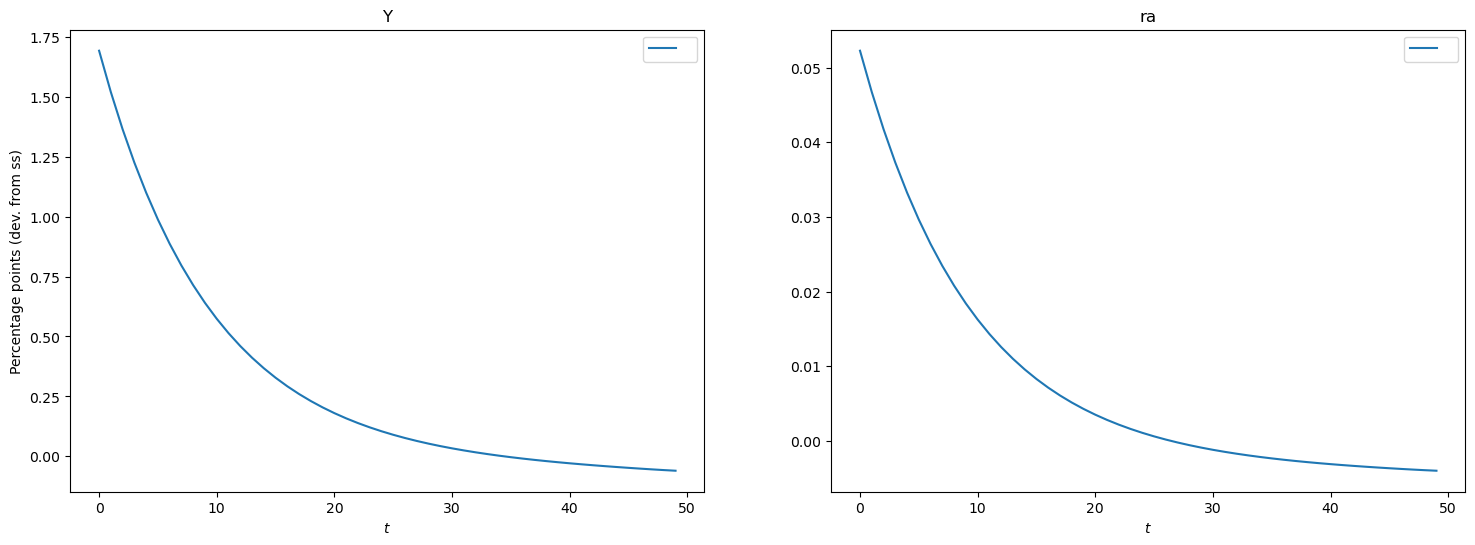

In [ ]:
show_irfs([irfs], ['Y', 'ra'])